## 1. Introduction and setup
This section will include the necessary imports and initial setup.

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# 2. Data Import and Preprocessing
Here let's import our data and preprocess it for analysis.
Let's first write down which systems are of interests: 
- HCl --- NH3     : 1.22 
- HCl --- Pyridine: 1.27
- HBr --- NH3     : 1.28 
- HI  --- NH3     : 1.32 

In the next cell we define a function to extract the SAPT(DFT) energy components from 1 of our calculations.

In [2]:
def extract_data_from_file(file_path, dmp2_file_path):
    data = {
        'Electrostatics': None,
        'Exchange': None,
        'Induction': None,
        'SAPT(DFT) Exch-Ind(S^Inf)': None,
        'SAPT(DFT) Exch-Ind(S^2)': None,
        'Delta HF': None,
        'Delta MP2': None,
        'SAPT0 Exch-Ind(S^Inf)': None,
        'SAPT0 Exch-Ind(S^2)': None,
        'Dispersion': None,
        'Total': None,
        'Distance': None
    }
    with open(dmp2_file_path, 'r') as file:
        lines = file.readlines()
        final_table_started = False
        for line in lines:
            if 'SAPT Results' in line:
                final_table_started = True
            if not final_table_started:
                continue
            parts = line.split()
            if len(parts) < 4:
                continue
            if final_table_started:
                if 'delta MP2,r (2)' in line:
                    data['Delta MP2'] = float(parts[5])
    with open(file_path, 'r') as file:
        lines = file.readlines()
        final_table_started = False
        dhf_segment = False
        int_segment = False                
        for line in lines:
            if 'SAPT(DFT): delta HF Segment' in line:
                dhf_segment = True
            if 'SAPT(DFT): Intermolecular Interaction Segment' in line:
                dhf_segment = False
                int_segment = True
            if 'SAPT(DFT) Results' in line:
                int_segment = False
                final_table_started = True
            if not final_table_started and not dhf_segment and not int_segment:
                continue
            parts = line.split()
            if len(parts) < 4:
                continue
            if dhf_segment:
                if 'Exch-Ind20,r' in line and not '(S^inf)' in line and '[kcal/mol]' in line:
                    data['SAPT0 Exch-Ind(S^2)'] = float(parts[3])
                if 'Exch-Ind20,r (S^inf)' in line and not '(A<-B)' in line and not '(A->B)' in line:
                    data['SAPT0 Exch-Ind(S^Inf)'] = 0.62751*float(parts[2])
            if int_segment:
                if 'Exch-Ind20,r (S^inf)' in line and not '(A<-B)' in line and not '(A->B)' in line:
                    data['SAPT(DFT) Exch-Ind(S^Inf)'] = 0.62751*float(parts[2])
            if final_table_started:
                if 'Electrostatics' in line and '[kcal/mol]' in line:
                    data['Electrostatics'] = float(parts[3])
                elif 'Exchange' in line and '[kcal/mol]' in line:
                    data['Exchange'] = float(parts[3])
                elif 'Induction' in line and '[kcal/mol]' in line and not '(A<-B)' in line and not '(A->B)' in line:
                    data['Induction'] = float(parts[3])
                elif 'Exch-Ind2,r' in line and '[kcal/mol]' in line:
                    data['SAPT(DFT) Exch-Ind(S^2)'] = float(parts[3])
                elif 'delta HF,r (2)' in line and '[kcal/mol]' in line:
                    data['Delta HF'] = float(parts[5])
                elif 'Dispersion' in line and '[kcal/mol]' in line:
                    data['Dispersion'] = float(parts[3])
                elif 'Total SAPT(DFT)' in line and '[kcal/mol]' in line:
                    data['Total'] = float(parts[4])
    # Extract distance from file name
    distance_match = re.search(r'_(\d+)_', file_path)
    if distance_match:
        data['Distance'] = int(distance_match.group(1))
    return data


In [3]:
def extract_dhf_from_file(file_path):
    dhf_data = {
        'Electrostatics': None,
        'Exchange': None,
        'Induction': None,
        'SAPT HF': None,
        'Total HF': None,
        'Delta HF': None,
        'Distance': None
    }
    with open(file_path, 'r') as file:
        lines = file.readlines()
        dhf_table_started = False
        for line in lines:
            if 'Partial SAPT(HF) Results, to compute Delta HF (dHF)' in line:
                dhf_table_started = True
            elif 'Partial SAPT(HF) Results, alternate SAPT0-like display' in line:
                dhf_table_started = False
            if not dhf_table_started:
                continue
            parts = line.split()
            if len(parts) < 4:
                continue
            if 'Electrostatics' in line and '[kcal/mol]' in line:
                dhf_data['Electrostatics'] = float(parts[3])
            elif 'Exchange' in line and '[kcal/mol]' in line:
                dhf_data['Exchange'] = float(parts[3])
            elif 'Induction' in line and '[kcal/mol]' in line and not '(A<-B)' in line and not '(A->B)' in line:
                dhf_data['Induction'] = float(parts[5])
            elif 'Subtotal' in line and '[kcal/mol]' in line:
                dhf_data['SAPT HF'] = float(parts[4])
            elif 'Total HF' in line and '[kcal/mol]' in line:
                dhf_data['Total HF'] = float(parts[4])
            elif 'Delta HF' in line and '[kcal/mol]' in line:
                dhf_data['Delta HF'] = float(parts[4])
    # Extract distance from file name
    distance_match = re.search(r'_(\d+)_', file_path)
    if distance_match:
        dhf_data['Distance'] = int(distance_match.group(1))
    return dhf_data


Subsequently we define a function to extract the same SAPT(DFT) components from the original Boese dimers calculations

In [4]:
def load_boese_dimers(file_path):
    boese_dimers = pd.read_csv(file_path, sep='\s+', comment='#', skiprows=4, names=['System', 'Electrostatics', 'Exchange', 'Induction', 'Delta HF', 'Dispersion', 'Total'])
    boese_dimers['Distance'] = boese_dimers['System'].apply(lambda x: int(x.split('_')[1]) if '_' in x else None)
    boese_dimers = boese_dimers.dropna(subset=['Distance'])
    return boese_dimers

Next we define a function that collects the benchmark datas

In [5]:
def load_benchmark(file_path):
    benchmark = pd.read_csv(file_path, sep='\s+', comment='#', skiprows=4, names=['System', 'Total CCSD(T)/CBS'])
    benchmark['Distance'] = benchmark['System'].apply(lambda x: int(x.split('_')[1]) if '_' in x else None)
    benchmark = benchmark.dropna(subset=['Distance'])
    return benchmark

Next we define a function to collect our datas by system in a Pandas Data Frame

In [6]:
def collect_data(directory, dmp2_directory, patterns):
    all_data = []
    for pattern in patterns:
        for file_name in os.listdir(directory):
            if re.match(pattern, file_name):
                file_path = os.path.join(directory, file_name)
                dmp2_file_path = os.path.join(dmp2_directory, file_name)
                if os.path.exists(dmp2_file_path):  # Check if the file exists in dmp2_directory
                    data = extract_data_from_file(file_path, dmp2_file_path)
                    all_data.append(data)
                else:
                    print(f"Warning: {dmp2_file_path} not found.")
    return pd.DataFrame(all_data)

In [7]:
def collect_dhf_data(directory, patterns):
    all_dhf_data = []
    for pattern in patterns:
        for file_name in os.listdir(directory):
            if re.match(pattern, file_name):
                file_path = os.path.join(directory, file_name)
                dhf_data = extract_dhf_from_file(file_path)
                all_dhf_data.append(dhf_data)
    return pd.DataFrame(all_dhf_data)

In [8]:
def save_my_dimers(my_dimers, system):
    file_name = f'/home/evanich/boese_dimers_calc/my_dimers_{system}.csv'
    my_dimers.to_csv(file_name, index=False)
    print(f"My dimers saved to {file_name}")

In [9]:
def save_my_dimers2(my_dimers, system):
    file_name = f'/home/evanich/boese_dimers_calc/aug_cc_pvqz_calc/my_dimers_au_cc_pvqz_{system}.csv'
    my_dimers.to_csv(file_name, index=False)
    print(f"My dimers saved to {file_name}")

In [10]:
def save_filtered_boese_dimers(boese_dimers_filtered, system):
    file_name = f'/home/evanich/boese_dimers_calc/boese_dimers_filtered_{system}.csv'
    boese_dimers_filtered.to_csv(file_name, index=False)
    print(f"Filtered Boese dimers saved to {file_name}")

In [11]:
def save_benchmark(benchmark, system):
    file_name = f'/home/evanich/boese_dimers_calc/benchmark_{system}.csv'
    benchmark.to_csv(file_name, index=False)
    print(f"Benchmark saved to {file_name}")

In [12]:
def save_dhf_my_dimers(my_dimers_dhf, system):
    file_name_dhf = f'dhf_my_dimers_{system}.csv'
    my_dimers_dhf.to_csv(file_name_dhf, index=False)
    print(f"DHF components from My dimers saved to {file_name_dhf}")

In [13]:
def save_dhf_my_dimers2(my_dimers_dhf, system):
    file_name_dhf = f'/home/evanich/boese_dimers_calc/aug_cc_pvqz_calc/dhf_my_dimers_aug_cc_pvqz_{system}.csv'
    my_dimers_dhf.to_csv(file_name_dhf, index=False)
    print(f"DHF components from My dimers saved to {file_name_dhf}")

# 3. Plotting the datas
Finally we define a function to plot our datas together with the original Boese dimers calculations in order to confront them

In [14]:
def plot_data(system, system_name):
    boese_file_path = f'/home/evanich/boese_dimers_calc/boese_dimers_filtered_{system}.csv'
    my_file_path = f'/home/evanich/boese_dimers_calc/my_dimers_{system}.csv'
    benchmark_path = f'/home/evanich/boese_dimers_calc/benchmark_{system}.csv'
    boese_dimers_filtered = pd.read_csv(boese_file_path)
    my_dimers = pd.read_csv(my_file_path)
    benchmark = pd.read_csv(benchmark_path)
    # Subtract Delta HF from Induction in my_dimers
    my_dimers['Induction'] = my_dimers['Induction'] - my_dimers['Delta HF']
    # Create a new dataset were we have subtracted Delta hF from he total also from both boese_dimers and my_dimers
    my_dimers['Total no DHF'] = my_dimers['Total'] - my_dimers['Delta HF']
    boese_dimers_filtered['Total no DHF'] = boese_dimers_filtered['Total'] - boese_dimers_filtered['Delta HF']
    # Create a new dataset were we have replaced S^2 with S^inf in Delta HF and Induction
    my_dimers['Induction (S^Inf)'] = my_dimers['Induction'] - my_dimers['SAPT(DFT) Exch-Ind(S^2)'] + my_dimers['SAPT(DFT) Exch-Ind(S^Inf)']
    my_dimers['Delta HF (S^Inf)'] = my_dimers['Delta HF'] + my_dimers['SAPT0 Exch-Ind(S^2)'] - my_dimers['SAPT0 Exch-Ind(S^Inf)']
    # Now create the new total
    my_dimers['Total (S^Inf)'] = my_dimers['Total no DHF'] - my_dimers['Induction'] + my_dimers['Induction (S^Inf)'] + my_dimers['Delta HF (S^Inf)']
    # Add Delta MP2 to Total
    my_dimers['Total + Delta MP2'] = my_dimers['Total'] + my_dimers['Delta MP2']
    my_dimers['Total (S^Inf) + Delta MP2'] = my_dimers['Total (S^Inf)'] + my_dimers['Delta MP2']
    boese_dimers_filtered['Total + Delta MP2'] = boese_dimers_filtered['Total'] + my_dimers['Delta MP2']

    #variables = ['Electrostatics', 'Exchange', 'Induction', 'Delta HF', 'Dispersion', 'Total', 'Total no DHF', 'Induction (S^Inf)', 'Delta HF (S^Inf)', 'Total (S^Inf)', 'Total + Delta MP2']
    variables = ['Electrostatics', 'Exchange', 'Induction', 'Delta HF', 'Dispersion', 'Total', 'Total no DHF']
    for variable in variables:
        plt.figure()
        plt.plot(my_dimers['Distance'], my_dimers[variable], marker='o', label=f'{variable} SAPT(DFT) Psi4')
        if variable in ['Induction', 'Delta HF', 'Total']:
            plt.plot(my_dimers['Distance'], my_dimers[f'{variable} (S^Inf)'], marker='D', label=f'{variable} (S^Inf) SAPT(DFT) Psi4')
        plt.plot(boese_dimers_filtered['Distance'], boese_dimers_filtered[variable], marker='x', label=f'Boese Dimers {variable}')
        if variable in ['Total', 'Total no DHF']:
            plt.plot(benchmark['Distance'], benchmark['Total CCSD(T)/CBS'], marker='v', label='Benchmark')
        plt.title(f'{variable} vs Distance for {system_name}')
        plt.xlabel('Distance (a.u.)')
        plt.ylabel(f'{variable} (kcal/mol)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()  # Adjust layout to prevent overlapping labels
        plt.show()
    plt.figure()
    plt.plot(my_dimers['Distance'], my_dimers['Total no DHF'], marker='o', label='SAPT(DFT) Psi4')
    plt.plot(boese_dimers_filtered['Distance'], boese_dimers_filtered['Total no DHF'], marker='x', label='SAPT(DFT) Boese Dimers')
    plt.plot(my_dimers['Distance'], my_dimers['Total'], marker='D', label='SAPT(DFT) + DHF Psi4')
    plt.plot(boese_dimers_filtered['Distance'], boese_dimers_filtered['Total'], marker='v', label='SAPT(DFT) + DHF Boese Dimers')
    plt.plot(my_dimers['Distance'], my_dimers['Total + Delta MP2'], marker='p', label='SAPT(DFT) Total + DHF + DMP2 Psi4')
    plt.plot(boese_dimers_filtered['Distance'], boese_dimers_filtered['Total + Delta MP2'], marker='*', label='SAPT(DFT) Total + DHF + DMP2(Psi4) Boese dimers')
    plt.plot(benchmark['Distance'], benchmark['Total CCSD(T)/CBS'], marker='P', label='Benchmark')
    plt.title(f'Total vs Distance for {system_name}')
    plt.xlabel('Distance (a.u.)')
    plt.ylabel(f'Energy (kcal/mol)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()  # Adjust layout to prevent overlapping labels
    plt.show()

    plt.figure()
    plt.plot(my_dimers['Distance'], my_dimers['Total + Delta MP2'], marker='o', label='SAPT(DFT) Total + DHF + DMP2 Psi4')
    plt.plot(my_dimers['Distance'], my_dimers['Total (S^Inf) + Delta MP2'], marker='P', label='SAPT(DFT) Total (S^Inf) + DHF + DMP2 Psi4')
    plt.plot(boese_dimers_filtered['Distance'], boese_dimers_filtered['Total + Delta MP2'], marker='x', label='SAPT(DFT) Total + DHF + DMP2(Psi4) Boese dimers')
    plt.plot(benchmark['Distance'], benchmark['Total CCSD(T)/CBS'], marker='v', label='Benchmark')
    plt.title(f'Total vs Distance for {system_name}')
    plt.xlabel('Distance (a.u.)')
    plt.ylabel(f'Energy (kcal/mol)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()  # Adjust layout to prevent overlapping labels
    plt.show()

    plt.figure()
    plt.plot(my_dimers['Distance'], my_dimers['Delta MP2'], marker='o', label='SAPT(DFT) Total + DHF + DMP2 Psi4')
    plt.plot(benchmark['Distance'], benchmark['Total CCSD(T)/CBS'], marker='v', label='Benchmark')
    plt.title(f'Total vs Distance for {system_name}')
    plt.xlabel('Distance (a.u.)')
    plt.ylabel(f'Energy (kcal/mol)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()  # Adjust layout to prevent overlapping labels

In [15]:
def plot_data_wcomponents(system, system_name):
    boese_file_path = f'boese_dimers_filtered_{system}.csv'
    my_file_path = f'my_dimers_{system}.csv'
    my_file_path_dhf = f'dhf_my_dimers_{system}.csv'
    boese_dimers_filtered = pd.read_csv(boese_file_path)
    my_dimers = pd.read_csv(my_file_path)
    my_dimers_dhf = pd.read_csv(my_file_path_dhf)
    # Subtract Delta HF from Induction in my_dimers
    my_dimers['Induction'] = my_dimers['Induction'] - my_dimers['Delta HF']
    variables = ['Electrostatics', 'Exchange', 'Induction', 'Delta HF',]
    for variable in variables:
        plt.figure()
        plt.plot(my_dimers['Distance'], my_dimers[variable], marker='o', label='SAPT(DFT) Psi4')
        plt.plot(my_dimers_dhf['Distance'], my_dimers_dhf[variable], marker='o', label='SAPT0 component Psi4')
        plt.plot(boese_dimers_filtered['Distance'], boese_dimers_filtered[variable], marker='x', label='Boese Dimers')
        plt.title(f'{variable} vs Distance for {system_name}')
        plt.xlabel('Distance (a.u.)')
        plt.ylabel(f'{variable} (kcal/mol)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()  # Adjust layout to prevent overlapping labels
        plt.show()

In [16]:
def plot_dhf_data(system, system_name):
    boese_file_path = f'boese_dimers_filtered_{system}.csv'
    my_file_path_dhf = f'dhf_my_dimers_{system}.csv'
    boese_dimers_filtered = pd.read_csv(boese_file_path)
    my_dimers_dhf = pd.read_csv(my_file_path_dhf)
    #variables = ['Electrostatics', 'Exchange', 'Induction', 'SAPT HF', 'Total HF', 'Delta HF']
    plt.figure()
    plt.plot(my_dimers_dhf['Distance'], my_dimers_dhf['Electrostatics'], marker='o', label='Electrostatics')
    plt.plot(my_dimers_dhf['Distance'], my_dimers_dhf['Exchange'], marker='o', label='Exchange')
    plt.plot(my_dimers_dhf['Distance'], my_dimers_dhf['Induction'], marker='o', label='Induction')
    plt.plot(my_dimers_dhf['Distance'], my_dimers_dhf['SAPT HF'], marker='o', label='Subtotal HF')
    plt.plot(my_dimers_dhf['Distance'], my_dimers_dhf['Total HF'], marker='o', label='Total HF')
    plt.plot(my_dimers_dhf['Distance'], my_dimers_dhf['Delta HF'], marker='o', label='Delta HF')
    plt.plot(boese_dimers_filtered['Distance'], boese_dimers_filtered['Delta HF'], marker='x', label='Boese Dimers Delta HF')
    plt.title(f'Delta HF components vs Distance for {system_name}')
    plt.xlabel('Distance (a.u.)')
    plt.ylabel(f'Component (kcal/mol)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()  # Adjust layout to prevent overlapping labels
    plt.show()

## 4. Running the code
Here we run the Python code and the functions previously defined.

Filtered Boese dimers saved to /home/evanich/boese_dimers_calc/boese_dimers_filtered_1.22.csv
My dimers saved to /home/evanich/boese_dimers_calc/my_dimers_1.22.csv
Benchmark saved to /home/evanich/boese_dimers_calc/benchmark_1.22.csv


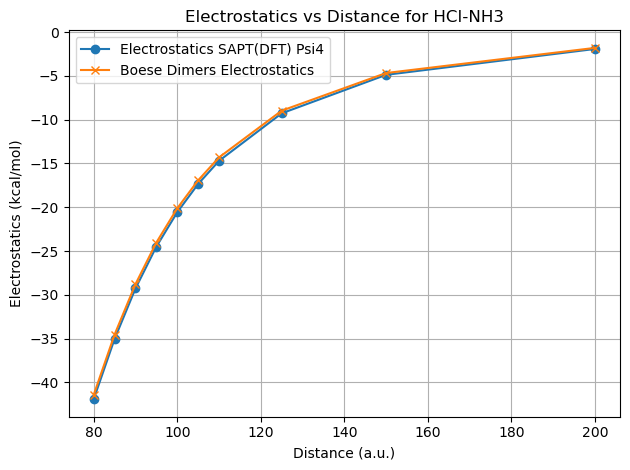

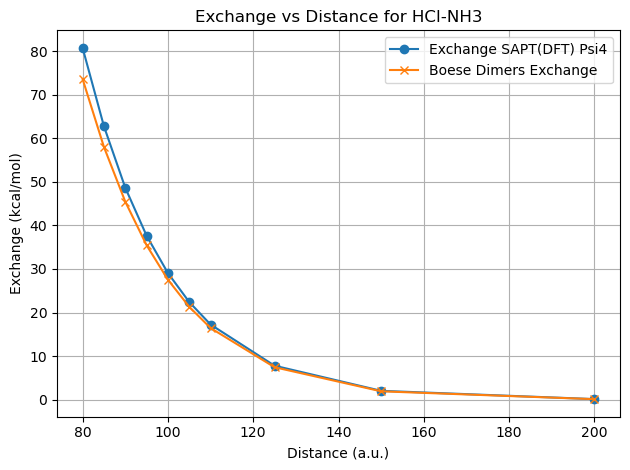

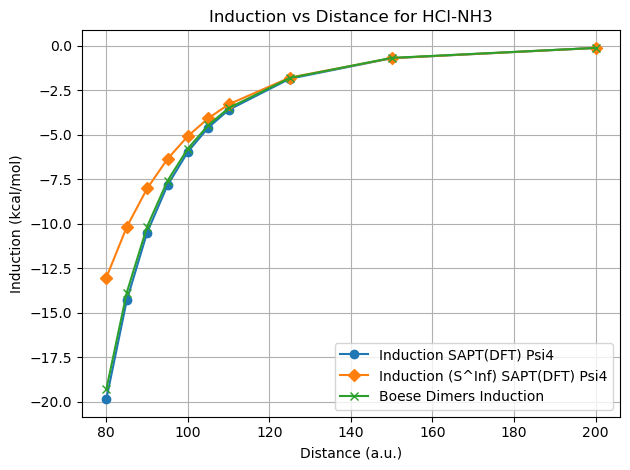

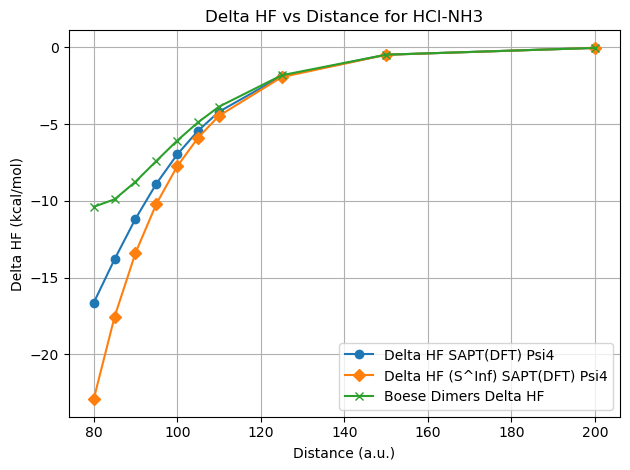

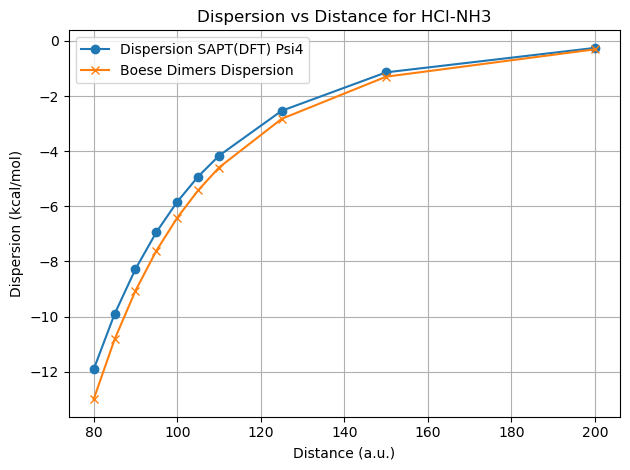

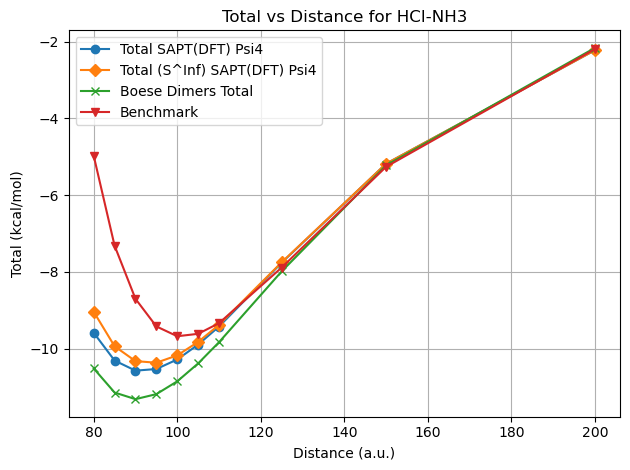

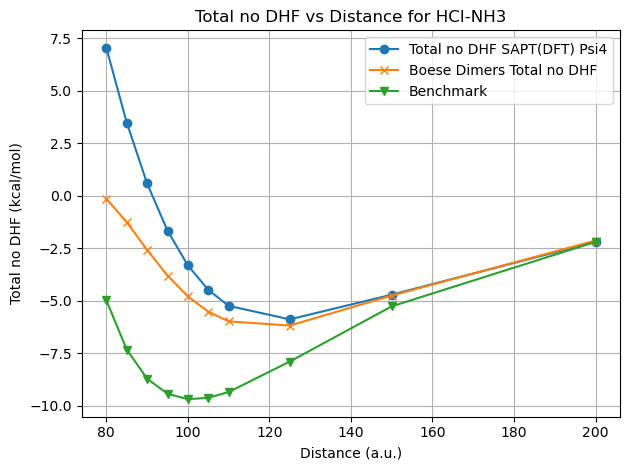

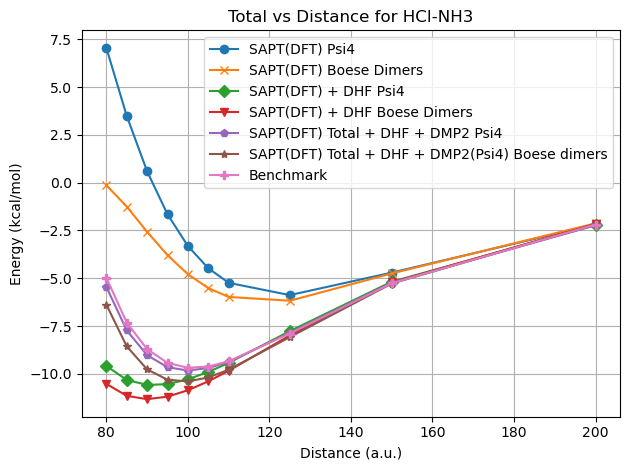

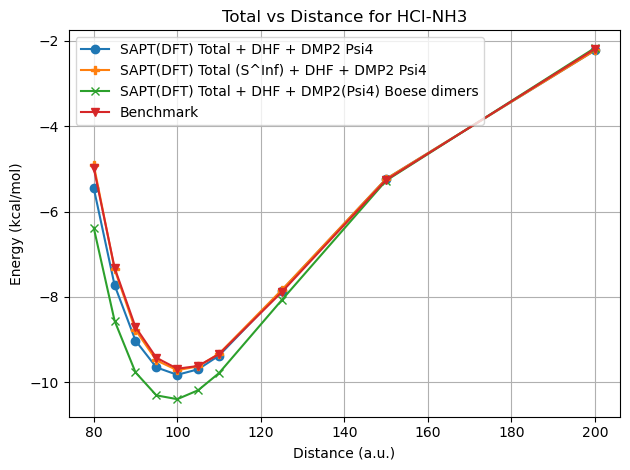

Filtered Boese dimers saved to /home/evanich/boese_dimers_calc/boese_dimers_filtered_1.27.csv
My dimers saved to /home/evanich/boese_dimers_calc/my_dimers_1.27.csv
Benchmark saved to /home/evanich/boese_dimers_calc/benchmark_1.27.csv


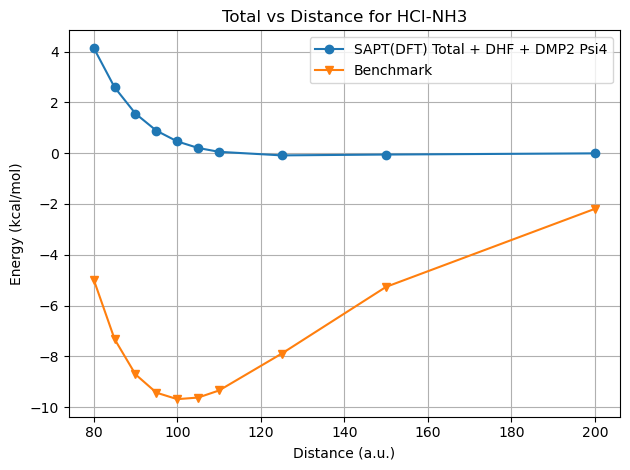

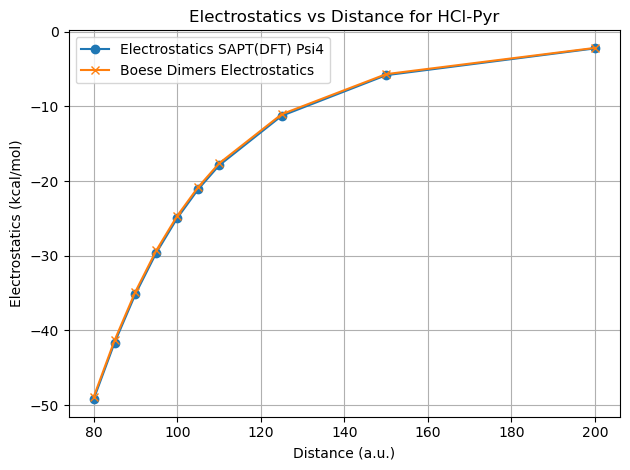

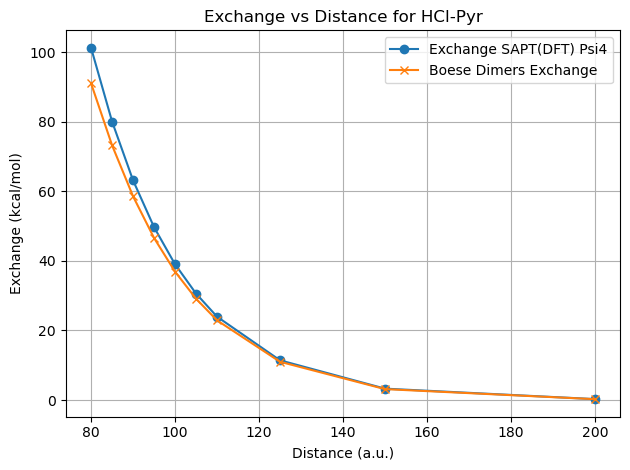

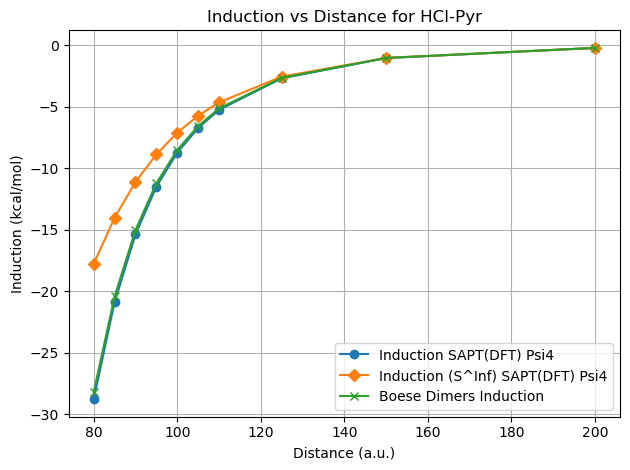

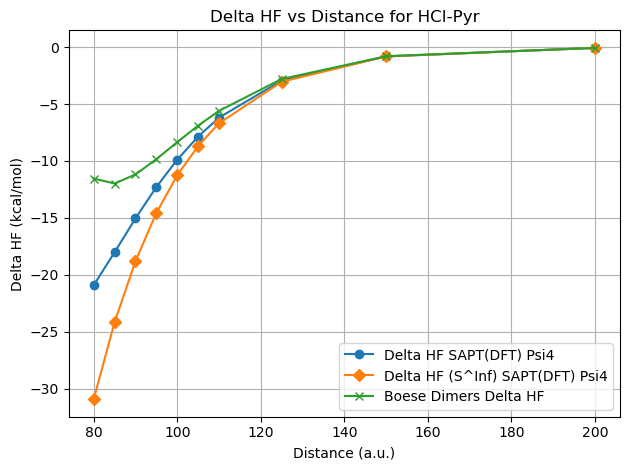

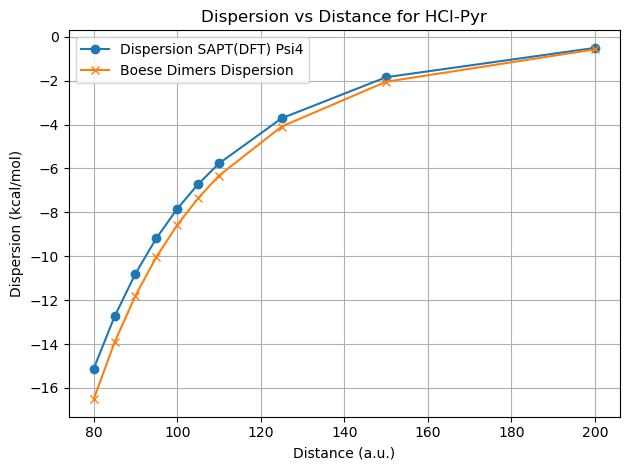

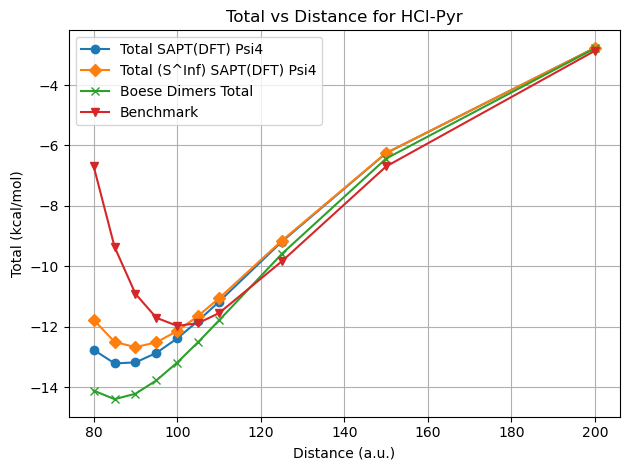

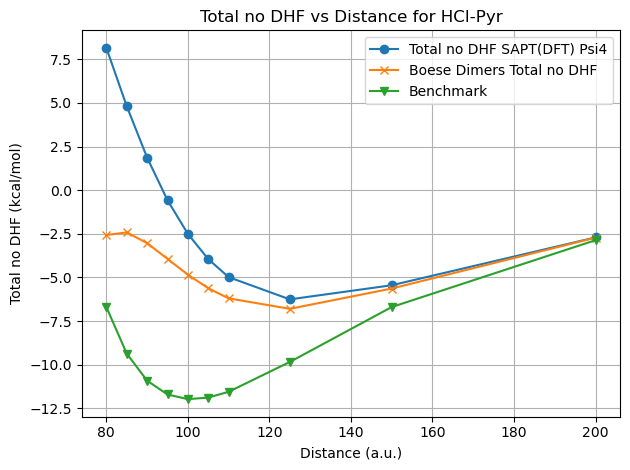

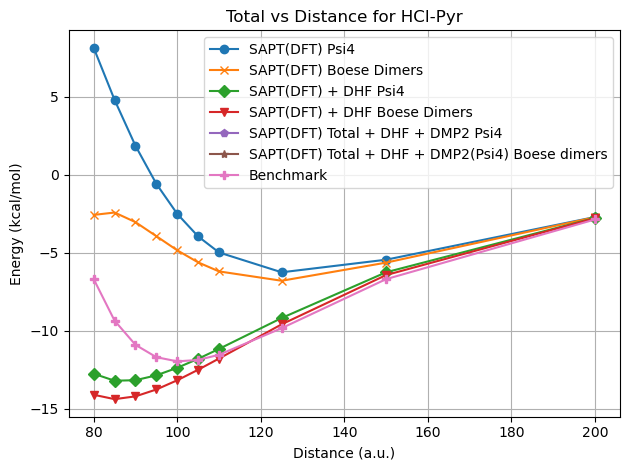

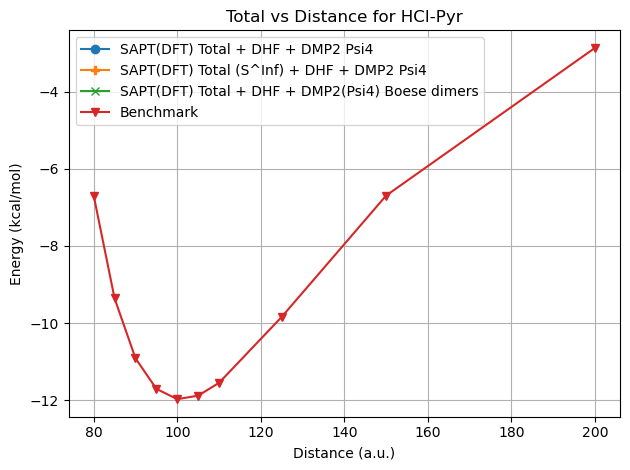

Filtered Boese dimers saved to /home/evanich/boese_dimers_calc/boese_dimers_filtered_1.28.csv
My dimers saved to /home/evanich/boese_dimers_calc/my_dimers_1.28.csv
Benchmark saved to /home/evanich/boese_dimers_calc/benchmark_1.28.csv


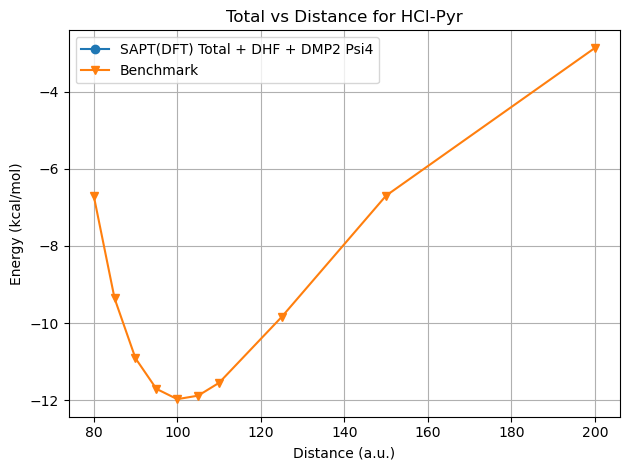

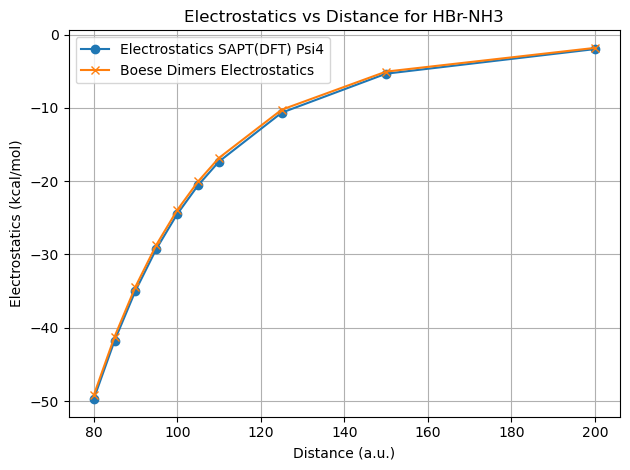

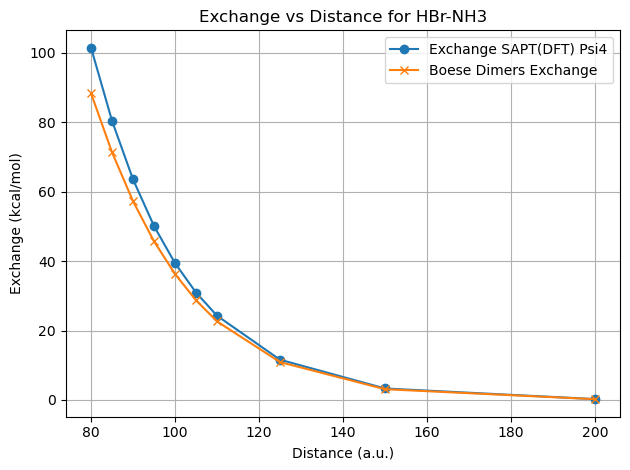

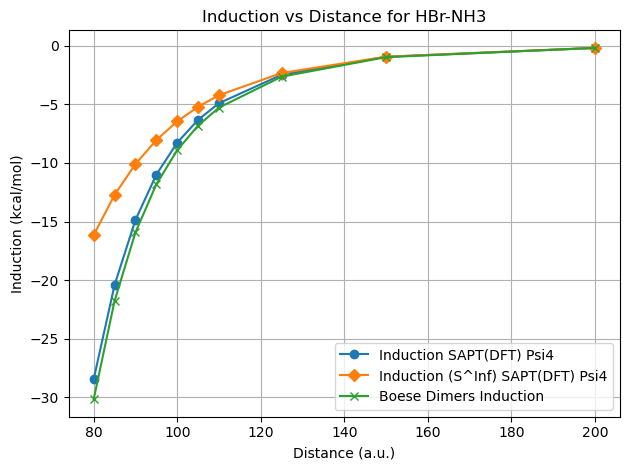

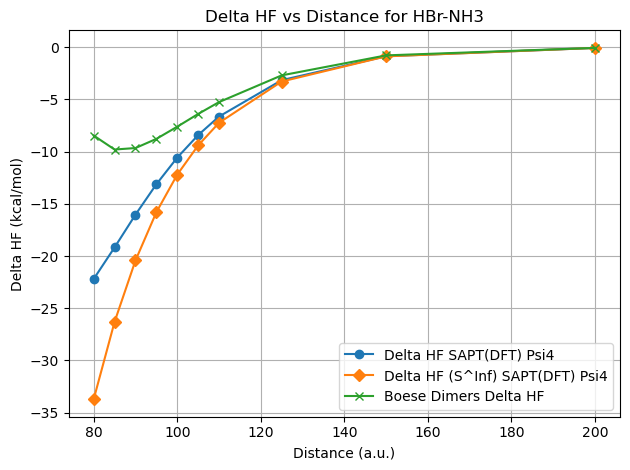

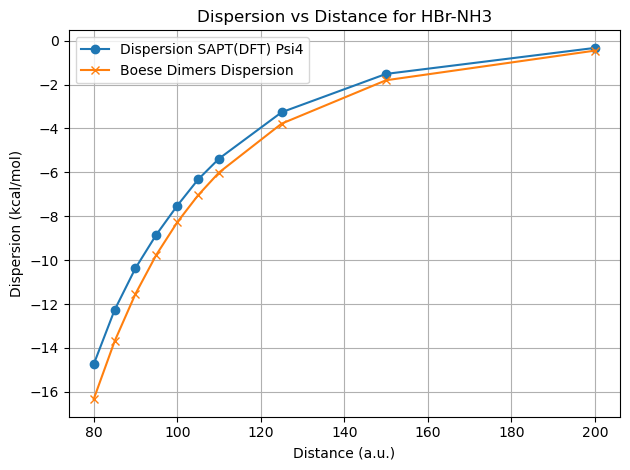

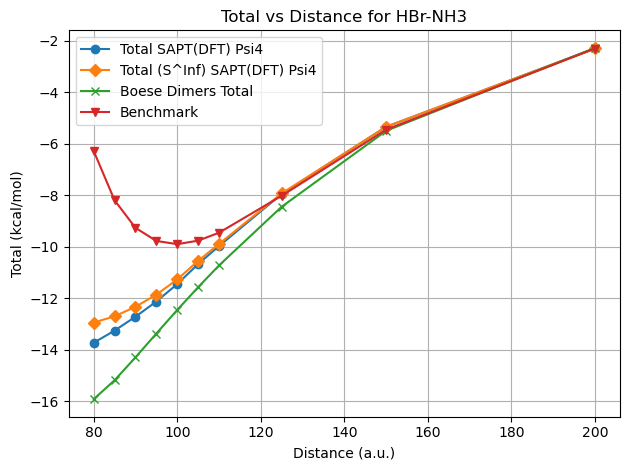

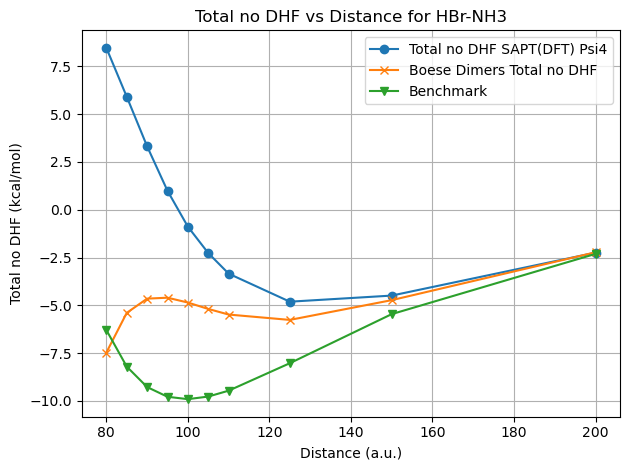

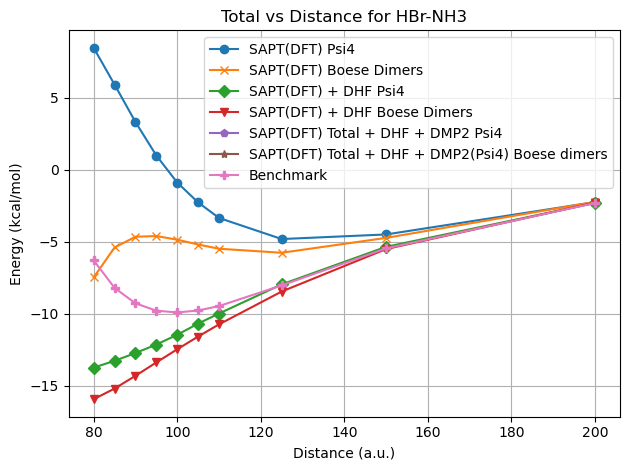

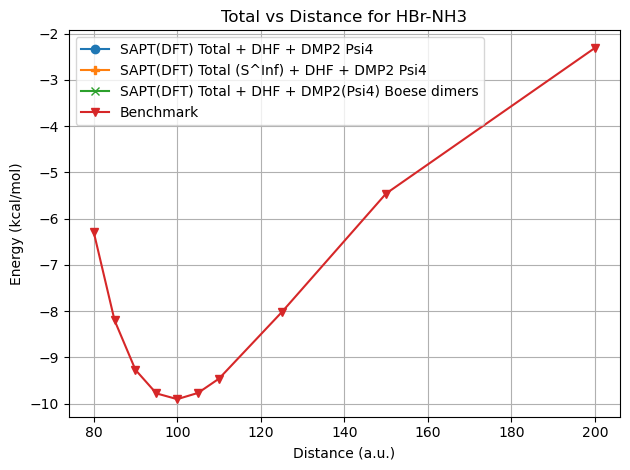

Filtered Boese dimers saved to /home/evanich/boese_dimers_calc/boese_dimers_filtered_1.32.csv
My dimers saved to /home/evanich/boese_dimers_calc/my_dimers_1.32.csv
Benchmark saved to /home/evanich/boese_dimers_calc/benchmark_1.32.csv


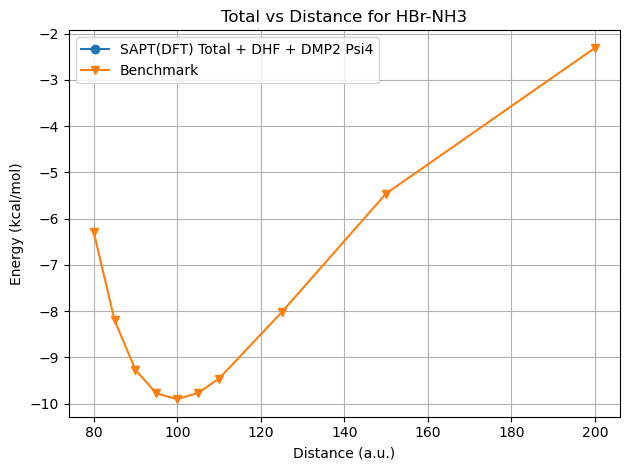

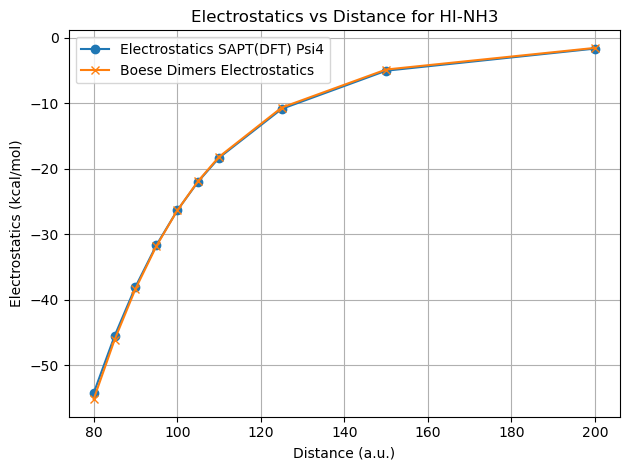

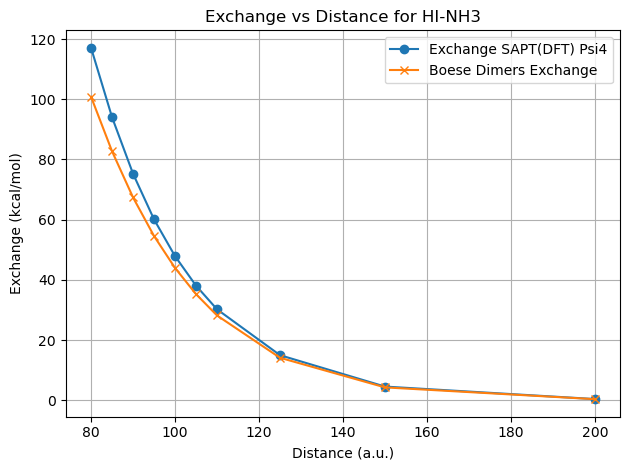

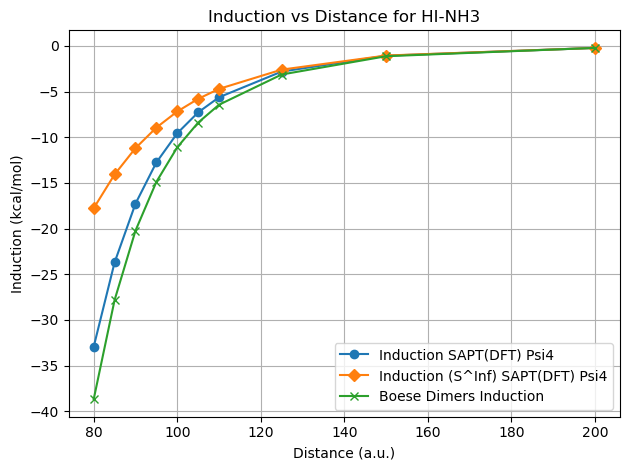

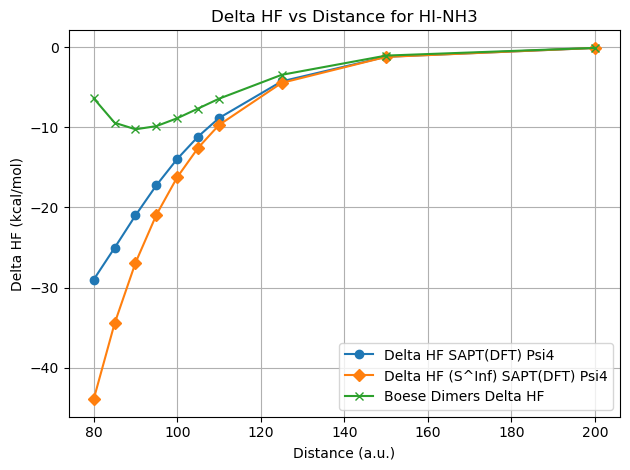

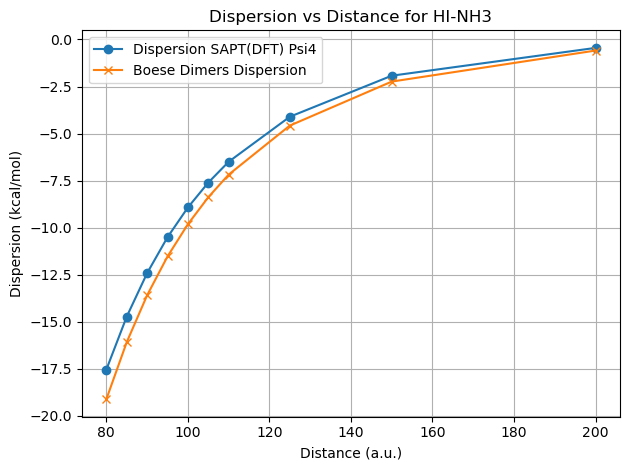

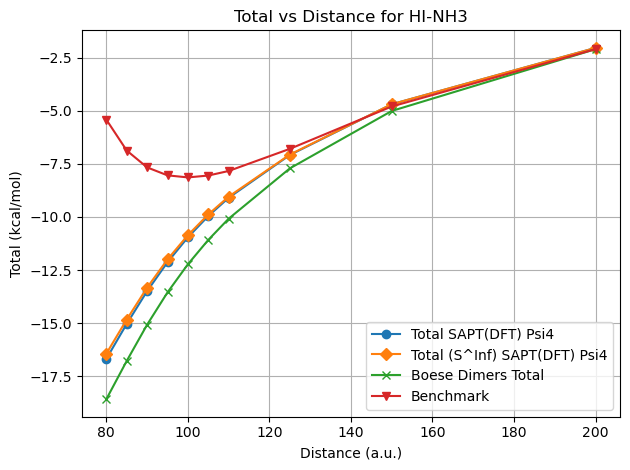

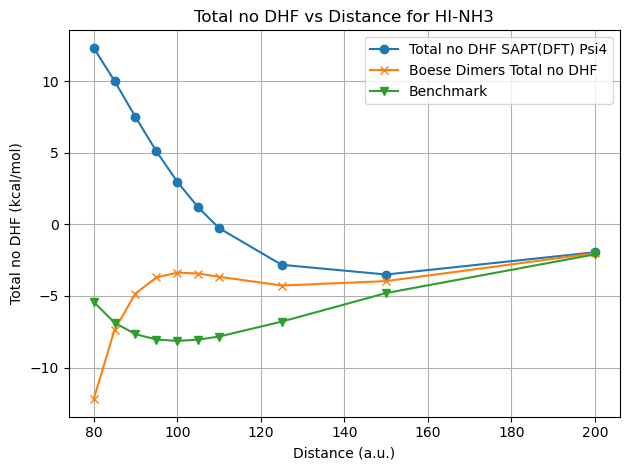

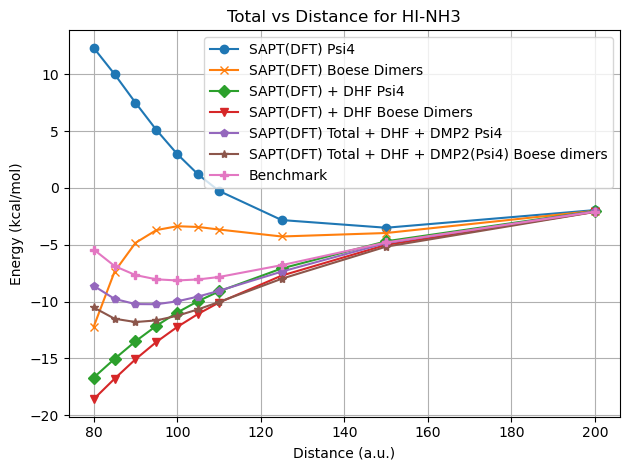

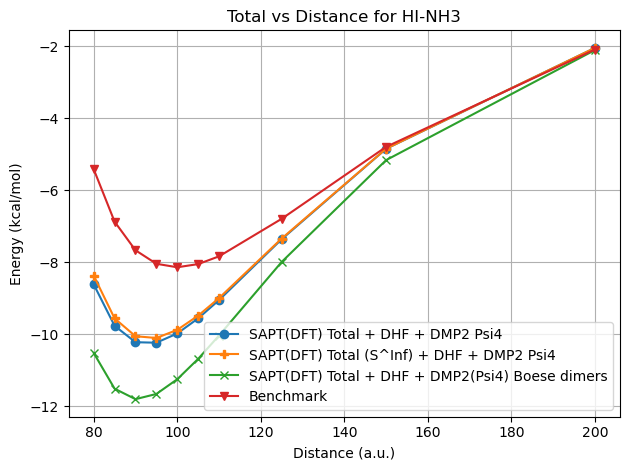

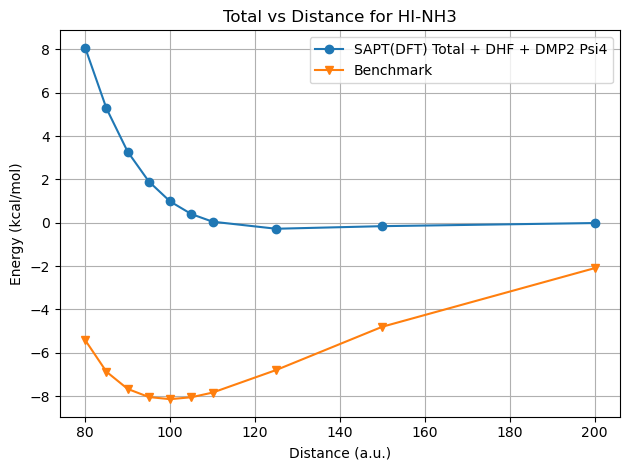

In [17]:
directory = '/home/evanich/boese_dimers_calc'
dmp2_directory = '/home/evanich/boese_dimers_calc/sapt2+mp2'
additional_file = '/home/evanich/NCIAtlas/tables/NCIA_HB300SPXx10/NCIA_HB300SPXx10_dft-sapt_pbe0.txt'
benchmark_file = '/home/evanich/NCIAtlas/tables/NCIA_HB300SPXx10/NCIA_HB300SPXx10_benchmark.txt'
#patterns = [r'1\.22.*\.out']
patterns = [r'1\.22.*\.out', r'1\.27.*\.out', r'1\.28.*\.out', r'1\.32.*\.out']
systems = {
    '1.22': 'HCl-NH3',
    '1.27': 'HCl-Pyr',
    '1.28': 'HBr-NH3',
    '1.32': 'HI-NH3'
}

boese_dimers = load_boese_dimers(additional_file)
benchmark = load_benchmark(benchmark_file)
#for system, system_name in systems.items():
#    my_dimers = collect_data(directory, [f'{system}.*\.out'])
#    boese_dimers_filtered = boese_dimers[boese_dimers['System'].str.startswith(system)]
#    plot_data(my_dimers, boese_dimers, system, system_name)
#    plot_boese_dimers(boese_dimers_filtered, system_name)
#    save_filtered_boese_dimers(boese_dimers_filtered, system)
#    plot_boese_dimers_from_file(f'boese_dimers_filtered_{system}.csv', system_name)

for system, system_name in systems.items():
    my_dimers = collect_data(directory, dmp2_directory, [f'{system}.*\.out'])
   #my_dimers_dhf = collect_dhf_data(directory, [f'{system}.*\.out'])
    boese_dimers_filtered = boese_dimers[boese_dimers['System'].str.startswith(system)]
    benchmark_filtered = benchmark[benchmark['System'].str.startswith(system)]
    save_filtered_boese_dimers(boese_dimers_filtered, system)
    save_my_dimers(my_dimers, system)
   #save_dhf_my_dimers(my_dimers_dhf, system) # commented because not needed anymore
    save_benchmark(benchmark_filtered, system)
    plot_data(system, system_name)
   #plot_data_wcomponents(system, system_name) # not needed anymore
   #plot_dhf_data(system, system_name) # not needed anymore


In [18]:
hcl_nh3 = f'my_dimers_1.22.csv'
hcl_nh3_df = pd.read_csv(hcl_nh3)
hcl_nh3_df


,Electrostatics,Exchange,Induction,SAPT(DFT) Exch-Ind(S^Inf),SAPT(DFT) Exch-Ind(S^2),Delta HF,Delta MP2,SAPT0 Exch-Ind(S^Inf),SAPT0 Exch-Ind(S^2),Dispersion,Total,Distance
0,-41.911354,80.716053,-36.487664,37.868474,31.040159,-16.635434,4.141913,33.845879,27.565118,-11.906770,-9.589734,80
1,-35.033777,62.732520,-28.108089,27.709370,23.589928,-13.800432,2.589034,24.583029,20.835251,-9.904503,-10.313849,85
2,-29.272144,48.634245,-21.666172,20.312103,17.839237,-11.166854,1.555829,17.892081,15.667696,-8.273279,-10.577350,90
3,-24.498916,37.625422,-16.724716,14.918509,13.440013,-8.879276,0.885458,13.048113,11.733865,-6.936734,-10.534943,95
4,-20.569638,29.055018,-12.936904,10.976511,10.095565,-6.971692,0.462411,9.533540,8.760013,-5.834287,-10.285810,100
5,-17.345085,22.398745,-10.032045,8.087955,7.564642,-5.423238,0.204178,6.978130,6.524326,-4.919994,-9.898379,105
6,-14.701656,17.240966,-7.802293,5.967439,5.657390,-4.189565,0.052878,5.116340,4.850833,-4.163570,-9.426554,110
7,-9.277819,7.795689,-3.745134,2.410590,2.346979,-1.881306,-0.087531,2.035091,1.982568,-2.534736,-7.761999,125
8,-4.882244,2.031763,-1.189330,0.545458,0.541021,-0.476383,-0.054725,0.448336,0.444899,-1.141341,-5.181153,150
9,-1.927889,0.130008,-0.167298,0.029438,0.029418,-0.030805,-0.007962,0.022697,0.022683,-0.254088,-2.219267,200


In [19]:
boese_dimers_filtered_hcl_nh3 = f'boese_dimers_filtered_1.22.csv'
boese_dimers_filtered_hcl_nh3_df = pd.read_csv(boese_dimers_filtered_hcl_nh3)
boese_dimers_filtered_hcl_nh3_df
#boese_dimers_hcl_nh3_sum = boese_dimers_filtered_hcl_nh3_df['Electrostatics'] + boese_dimers_filtered_hcl_nh3_df['Exchange'] + boese_dimers_filtered_hcl_nh3_df['Induction'] + boese_dimers_filtered_hcl_nh3_df['Delta HF'] + boese_dimers_filtered_hcl_nh3_df['Dispersion']
#boese_dimers_hcl_nh3_sum

,System,Electrostatics,Exchange,Induction,Delta HF,Dispersion,Total,Distance
0,1.22_080,-41.419,73.562,-19.289,-10.382,-12.992,-10.520,80.0
1,1.22_085,-34.536,57.979,-13.872,-9.896,-10.824,-11.148,85.0
2,1.22_090,-28.783,45.438,-10.168,-8.750,-9.057,-11.321,90.0
3,1.22_095,-24.028,35.439,-7.597,-7.395,-7.609,-11.190,95.0
4,1.22_100,-20.123,27.528,-5.782,-6.067,-6.413,-10.856,100.0
5,1.22_105,-16.926,21.307,-4.474,-4.875,-5.420,-10.389,105.0
6,1.22_110,-14.313,16.442,-3.513,-3.860,-4.592,-9.836,110.0
7,1.22_125,-8.976,7.447,-1.820,-1.813,-2.827,-7.988,125.0
8,1.22_150,-4.676,1.920,-0.695,-0.473,-1.298,-5.221,150.0
9,1.22_200,-1.806,0.118,-0.134,-0.032,-0.306,-2.160,200.0


Filtered Boese dimers saved to /home/evanich/boese_dimers_calc/boese_dimers_filtered_1.22.csv
My dimers saved to /home/evanich/boese_dimers_calc/aug_cc_pvqz_calc/my_dimers_au_cc_pvqz_1.22.csv
DHF components from My dimers saved to /home/evanich/boese_dimers_calc/aug_cc_pvqz_calc/dhf_my_dimers_aug_cc_pvqz_1.22.csv


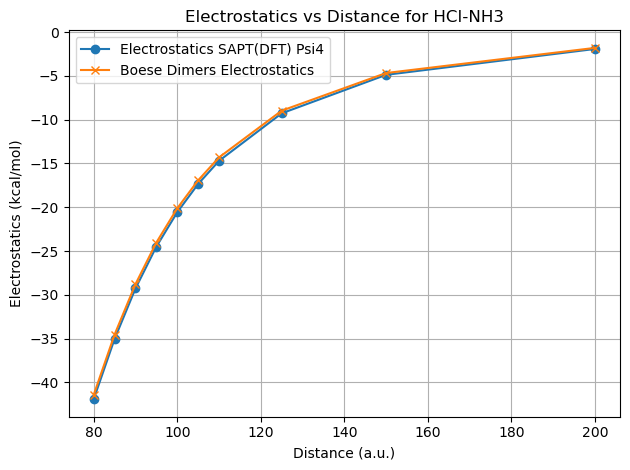

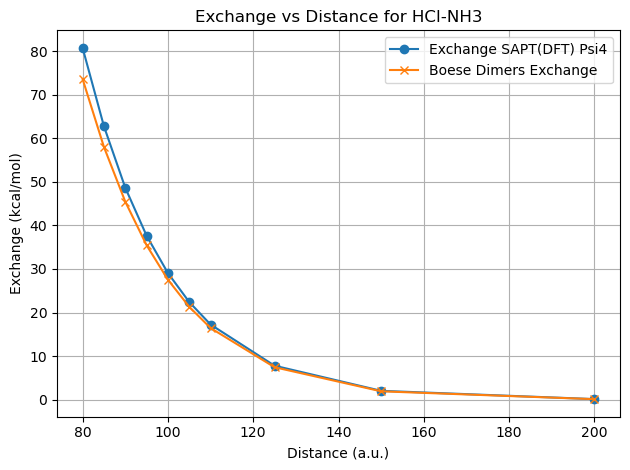

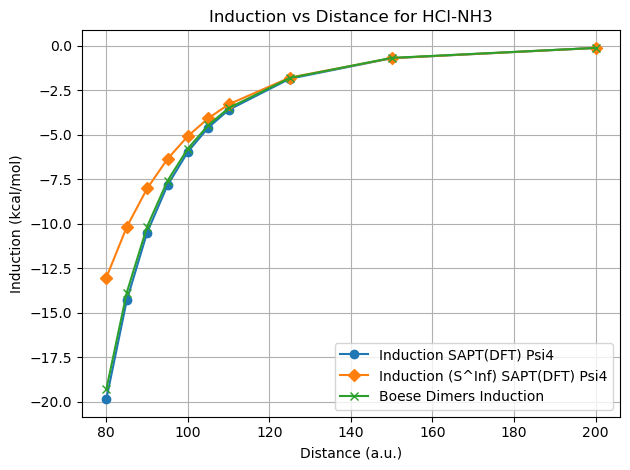

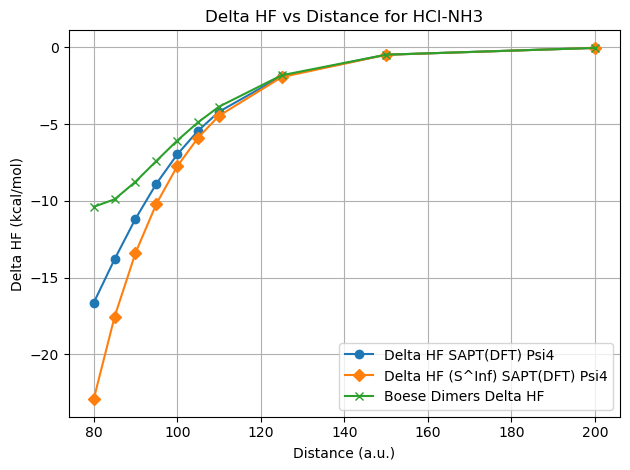

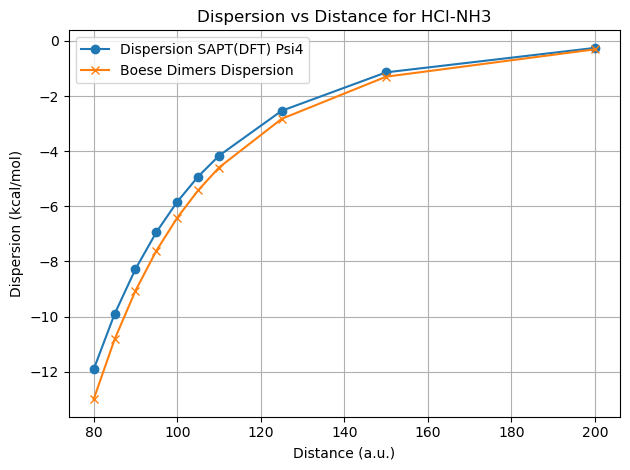

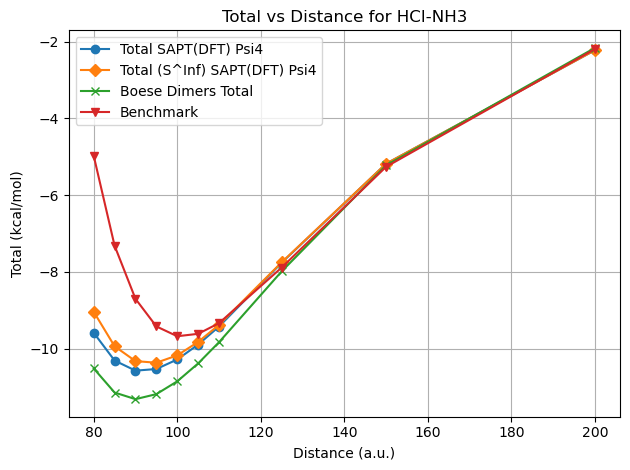

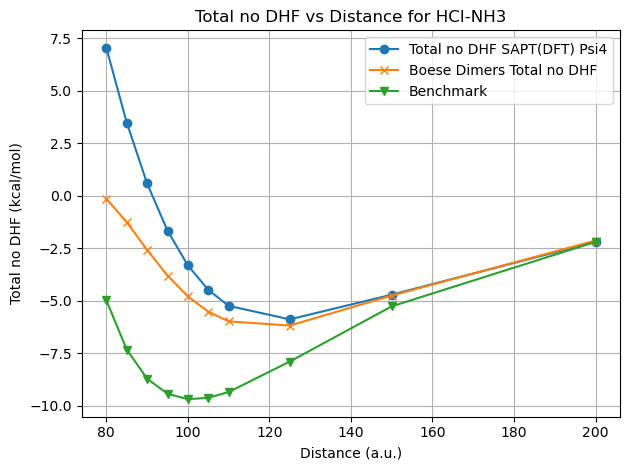

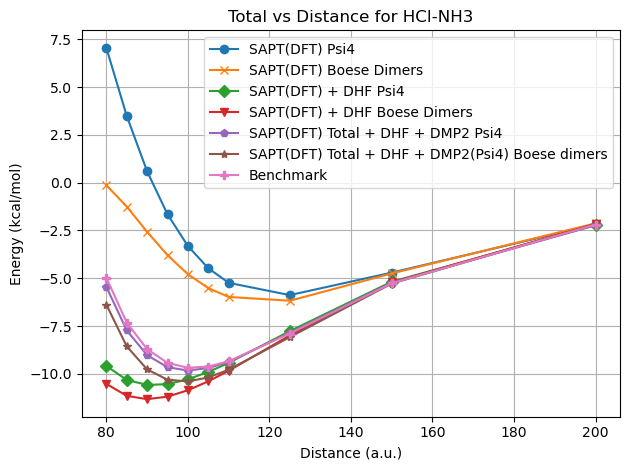

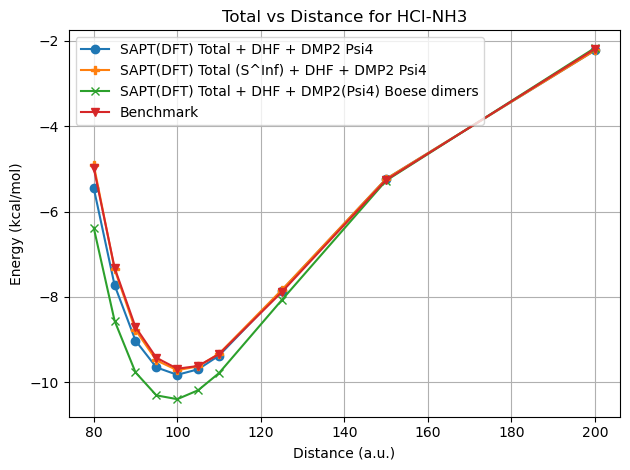

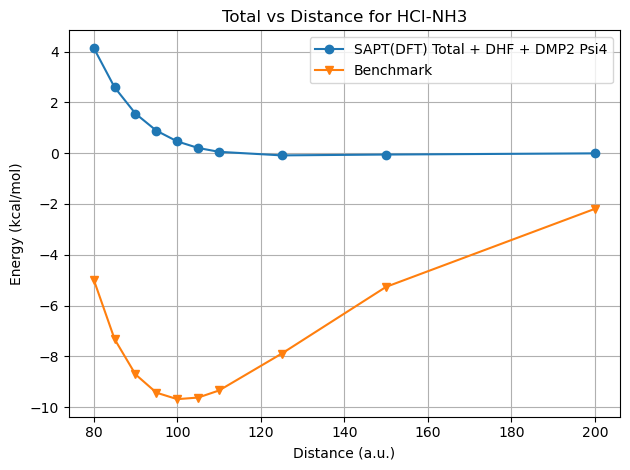

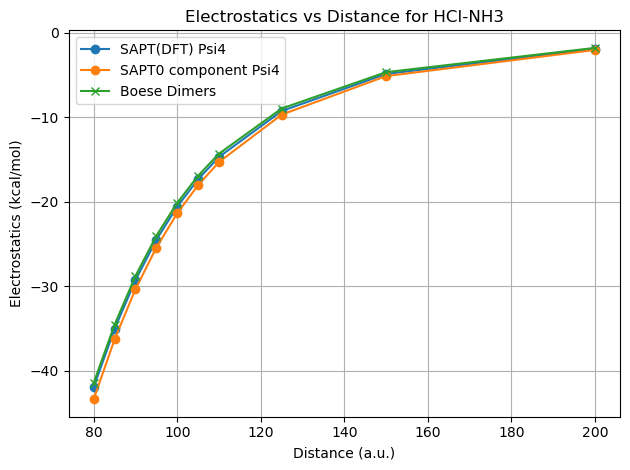

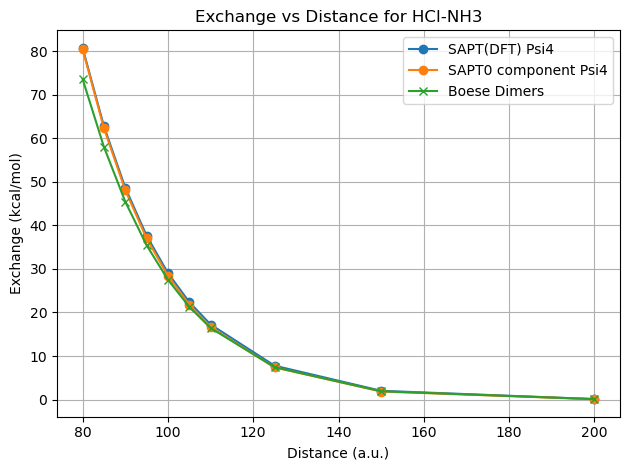

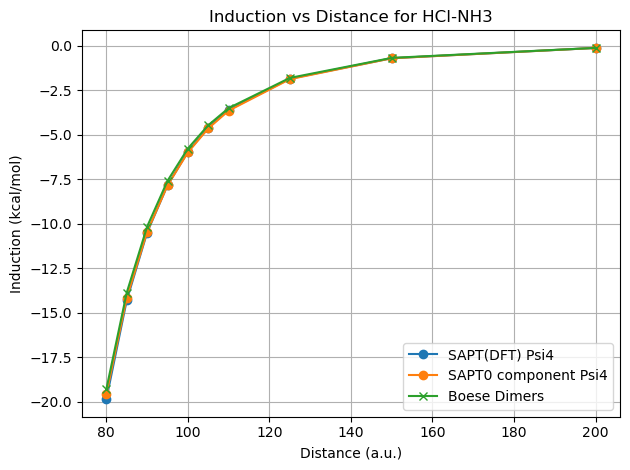

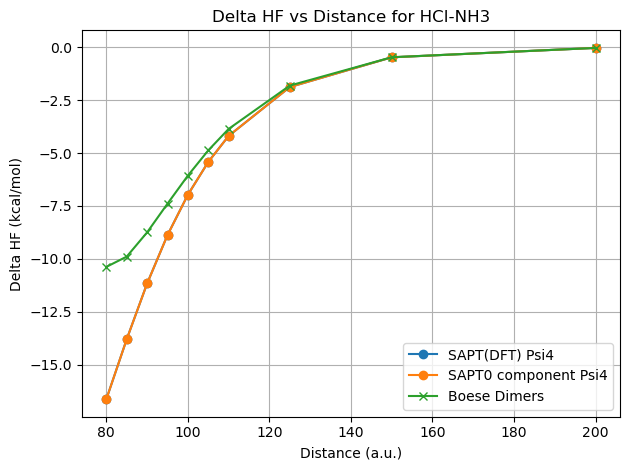

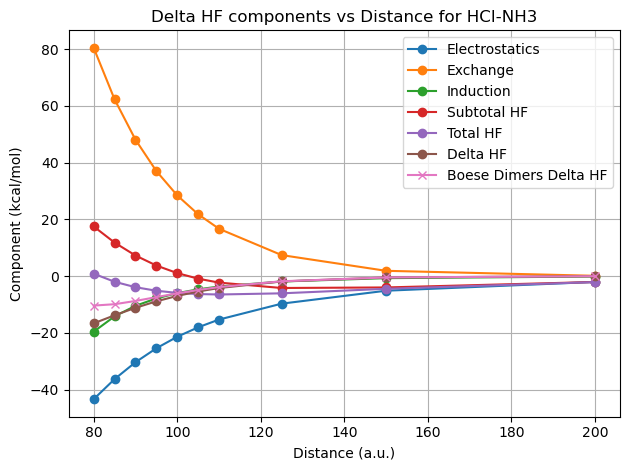

In [20]:
directory = '/home/evanich/boese_dimers_calc/aug_cc_pvqz_calc'
dmp2_directory
additional_file = '/home/evanich/NCIAtlas/tables/NCIA_HB300SPXx10/NCIA_HB300SPXx10_dft-sapt_pbe0.txt'
#patterns = [r'1\.22.*\.out']
patterns = [r'1\.22.*\.out']
systems = {
    '1.22': 'HCl-NH3',
}

boese_dimers = load_boese_dimers(additional_file)

#for system, system_name in systems.items():
#    my_dimers = collect_data(directory, [f'{system}.*\.out'])
#    boese_dimers_filtered = boese_dimers[boese_dimers['System'].str.startswith(system)]
#    plot_data(my_dimers, boese_dimers, system, system_name)
#    plot_boese_dimers(boese_dimers_filtered, system_name)
#    save_filtered_boese_dimers(boese_dimers_filtered, system)
#    plot_boese_dimers_from_file(f'boese_dimers_filtered_{system}.csv', system_name)

for system, system_name in systems.items():

    my_dimers2 = collect_data(directory, dmp2_directory, [f'aug_cc_pvqz_calc/{system}.*\.out'])
    my_dimers_dhf = collect_dhf_data(directory, [f'aug_cc_pvqz_calc/{system}.*\.out'])
    boese_dimers_filtered = boese_dimers[boese_dimers['System'].str.startswith(system)]
    save_filtered_boese_dimers(boese_dimers_filtered, system)
    save_my_dimers2(my_dimers2, system)
    save_dhf_my_dimers2(my_dimers_dhf, system)
    plot_data(system, system_name)
    plot_data_wcomponents(system, system_name)
    plot_dhf_data(system, system_name)